# TravelMind — Refund Agent (Converse API + Tools)

Runnable build for the **Bedrock Model Selection Lab**. You will wire a refund assistant that checks eligibility, presents options with a dynamically generated coupon, and **cannot issue refunds** — because the refund-execution tool simply does not exist.

**Anchor:** TravelMind airline support · region `us-east-1` · PNR `JX48Q2`

Order of the build: a basic call → the dummy tools → single-turn tool use → the multi-turn agent loop → a vision pass on a ticket image.

## Setup

**VS Code**
1. Create and activate a venv, then run the install cell below.
2. Set credentials: `aws configure`, or env vars `AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`, `AWS_DEFAULT_REGION=us-east-1`.
3. Select the venv as the kernel and run top to bottom.

**Google Colab**
1. Run the install cell.
2. Set credentials in a cell via `os.environ[...]` or Colab secrets (include `AWS_DEFAULT_REGION=us-east-1`).
3. Run top to bottom.

You need Bedrock model access enabled for the model IDs below in `us-east-1`.

In [ ]:
%pip install -q boto3 pillow

In [4]:
import json, time, random
import boto3
from botocore.config import Config
from botocore.exceptions import ClientError, NoCredentialsError

REGION = "us-east-1"

# All three lab models. Change MODEL_ID to re-run the SAME code on a different model.
NOVA_LITE = "us.amazon.nova-2-lite-v1:0"
HAIKU_45  = "us.anthropic.claude-haiku-4-5-20251001-v1:0"
SONNET_45 = "us.anthropic.claude-sonnet-4-5-20250929-v1:0"

MODEL_ID = HAIKU_45            # bootcamp anchor; swap to NOVA_LITE or SONNET_45 freely
PRICE = {                     # USD per 1M tokens (in, out) for the usage->cost tie-back
    NOVA_LITE: (0.30, 2.50),
    HAIKU_45:  (1.00, 5.00),
    SONNET_45: (3.00, 15.00),
}

# Adaptive retries handle Bedrock throttling automatically.
bedrock = boto3.client(
    "bedrock-runtime", region_name=REGION,
    config=Config(retries={"max_attempts": 5, "mode": "adaptive"},
                  read_timeout=120, connect_timeout=10),
)

# PRODUCTION: use an IAM role (instance/task role), never access keys in code.
# IAM action is bedrock:InvokeModel -- bedrock:Converse is NOT a valid action.

In [5]:
def preflight():
    try:
        boto3.client("sts", region_name=REGION).get_caller_identity()
    except NoCredentialsError:
        print("No AWS credentials found. Run `aws configure` or set env vars.")
        return
    try:
        bedrock.converse(modelId=MODEL_ID,
                         messages=[{"role": "user", "content": [{"text": "ping"}]}],
                         inferenceConfig={"maxTokens": 5})
        print(f"OK: credentials valid and {MODEL_ID} is reachable in {REGION}.")
    except ClientError as e:
        code = e.response["Error"]["Code"]
        print(f"Reached AWS but Converse failed: {code} - {e.response['Error']['Message']}")
        if code == "AccessDeniedException":
            print("-> Enable model access for this model in the Bedrock console (us-east-1).")

preflight()

OK: credentials valid and us.anthropic.claude-haiku-4-5-20251001-v1:0 is reachable in us-east-1.


## 1. The simplest possible call

One `converse` call. The response carries `usage` (your real token counts), `stopReason`, and `metrics.latencyMs`.

In [6]:
def say(text, model_id=MODEL_ID, system=None, max_tokens=300, temperature=0.2):
    kw = dict(modelId=model_id,
              messages=[{"role": "user", "content": [{"text": text}]}],
              inferenceConfig={"maxTokens": max_tokens, "temperature": temperature})
    if system:
        kw["system"] = [{"text": system}]
    resp = bedrock.converse(**kw)
    out = "".join(b.get("text", "") for b in resp["output"]["message"]["content"])
    u = resp["usage"]
    p_in, p_out = PRICE[model_id]
    cost = u["inputTokens"] / 1e6 * p_in + u["outputTokens"] / 1e6 * p_out
    print(out)
    print()
    print(f"[in={u['inputTokens']} out={u['outputTokens']} "
          f"latency={resp['metrics']['latencyMs']}ms cost=${cost:.6f}]")
    return out

_ = say("In one sentence, what is a multi-city flight itinerary?")

A multi-city flight itinerary is a trip that includes flights between more than two cities, rather than a simple round trip from one city to another.

[in=22 out=35 latency=879ms cost=$0.000197]


## 2. The tools — business logic lives in code, not in the model

Two tools the model may call. There is **deliberately no `execute_refund` tool**: the model can read eligibility and present options, but it has no path to move money. That boundary is enforced here, by omission — not by asking the prompt nicely.

In [7]:
NON_REFUNDABLE_FARES = {"BASIC", "PROMO", "SAVER"}

def check_refund_eligibility(pnr: str, fare_class: str, hours_to_departure: float) -> dict:
    """DUMMY logic. Production queries the booking system (PSS)."""
    fare = (fare_class or "").upper()
    if fare in NON_REFUNDABLE_FARES:
        return {"pnr": pnr, "eligible": False,
                "reason": f"Fare class {fare} is non-refundable per fare rules."}
    if hours_to_departure < 2:
        return {"pnr": pnr, "eligible": False,
                "reason": "Inside the 2-hour pre-departure cutoff; refund not permitted."}
    penalty = 0 if hours_to_departure > 72 else 25
    return {"pnr": pnr, "eligible": True, "refund_percent": 100 - penalty,
            "penalty_percent": penalty, "reason": "Refundable fare within the window."}

def generate_coupon_offer(pnr: str, base_refund_percent: int) -> dict:
    """DUMMY retention offer -- a travel credit as an ALTERNATIVE to cash."""
    bonus = random.choice([10, 15, 20])
    return {"pnr": pnr, "coupon_code": f"STAY{bonus}-{pnr[-4:]}",
            "coupon_value_percent": base_refund_percent + bonus,
            "validity_days": 90, "note": "Travel credit alternative to a cash refund."}

# NOTE: no execute_refund(). The capability boundary IS the absence of the tool.

TOOL_FUNCTIONS = {
    "check_refund_eligibility": check_refund_eligibility,
    "generate_coupon_offer": generate_coupon_offer,
}

def dispatch(name, args):
    fn = TOOL_FUNCTIONS.get(name)
    return fn(**args) if fn else {"error": f"Unknown tool: {name}"}

In [8]:
TOOL_CONFIG = {
    "tools": [
        {"toolSpec": {
            "name": "check_refund_eligibility",
            "description": "Decide whether a booking can be refunded, from fare rules and timing.",
            "inputSchema": {"json": {
                "type": "object",
                "properties": {
                    "pnr": {"type": "string", "description": "Booking reference, e.g. JX48Q2"},
                    "fare_class": {"type": "string"},
                    "hours_to_departure": {"type": "number"}},
                "required": ["pnr", "fare_class", "hours_to_departure"]}}}},
        {"toolSpec": {
            "name": "generate_coupon_offer",
            "description": "Generate a travel-credit coupon as an alternative to a cash refund.",
            "inputSchema": {"json": {
                "type": "object",
                "properties": {
                    "pnr": {"type": "string"},
                    "base_refund_percent": {"type": "integer"}},
                "required": ["pnr", "base_refund_percent"]}}}},
    ],
    "toolChoice": {"auto": {}},
}

SYSTEM_PROMPT = (
    "You are TravelMind's refund assistant. Use check_refund_eligibility to decide "
    "eligibility -- never assume or invent it. If refundable, present the options AND a "
    "coupon alternative via generate_coupon_offer. If not, explain why and still offer the "
    "coupon. You cannot issue refunds; tell the customer the next step is to confirm, after "
    "which a secure human-reviewed process completes it."
)

## 3. One turn — watch the model ask for a tool

Send a refund question. The model will not answer yet — it returns `stopReason == "tool_use"` and a `toolUse` block telling you which tool to run and with what arguments.

In [9]:
messages = [{"role": "user", "content": [
    {"text": "Cancel and refund PNR JX48Q2, SAVER fare, flight in 30 hours."}]}]

resp = bedrock.converse(modelId=MODEL_ID, system=[{"text": SYSTEM_PROMPT}],
                        messages=messages, toolConfig=TOOL_CONFIG,
                        inferenceConfig={"maxTokens": 1024, "temperature": 0.0})

print("stopReason:", resp["stopReason"])
for block in resp["output"]["message"]["content"]:
    if "toolUse" in block:
        print("tool requested:", block["toolUse"]["name"])
        print("arguments:", json.dumps(block["toolUse"]["input"], indent=2))
    elif "text" in block:
        print("text:", block["text"])

stopReason: tool_use
text: I'll check your refund eligibility for that booking.
tool requested: check_refund_eligibility
arguments: {
  "pnr": "JX48Q2",
  "fare_class": "SAVER",
  "hours_to_departure": 30
}


## 4. The full agent — multi-turn tool loop

Run the requested tools, hand the results back as `toolResult`, and call again. Repeat until the model stops asking for tools. A `MAX_TURNS` guard caps tool round-trips (cost and safety).

In [10]:
MAX_TURNS = 6

def run_agent(user_text, model_id=MODEL_ID, verbose=True):
    messages = [{"role": "user", "content": [{"text": user_text}]}]
    tin = tout = 0
    for _ in range(MAX_TURNS):
        resp = bedrock.converse(modelId=model_id, system=[{"text": SYSTEM_PROMPT}],
                                messages=messages, toolConfig=TOOL_CONFIG,
                                inferenceConfig={"maxTokens": 1024, "temperature": 0.0})
        tin += resp["usage"]["inputTokens"]
        tout += resp["usage"]["outputTokens"]
        out_msg = resp["output"]["message"]
        messages.append(out_msg)                       # keep the assistant turn in history

        if resp["stopReason"] != "tool_use":
            final = "".join(b.get("text", "") for b in out_msg["content"])
            p_in, p_out = PRICE[model_id]
            cost = tin / 1e6 * p_in + tout / 1e6 * p_out
            if verbose:
                print(final)
                print()
                print(f"[in={tin} out={tout} cost=${cost:.6f}]")
            return final

        results = []
        for block in out_msg["content"]:
            if "toolUse" in block:
                tu = block["toolUse"]
                if verbose:
                    print(f"  -> calling {tu['name']}({tu['input']})")
                results.append({"toolResult": {
                    "toolUseId": tu["toolUseId"],
                    "content": [{"json": dispatch(tu["name"], tu["input"])}],
                    "status": "success"}})
        messages.append({"role": "user", "content": results})
    return "Stopped: hit MAX_TURNS."

print("=== SAVER fare, 30h (should DENY + offer coupon) ===")
run_agent("Cancel and refund PNR JX48Q2, SAVER fare, flight in 30 hours.")

=== SAVER fare, 30h (should DENY + offer coupon) ===
  -> calling check_refund_eligibility({'pnr': 'JX48Q2', 'fare_class': 'SAVER', 'hours_to_departure': 30})
  -> calling generate_coupon_offer({'pnr': 'JX48Q2', 'base_refund_percent': 100})
**Great news!** I've generated a travel credit offer:

- **Coupon Code:** STAY20-48Q2
- **Value:** 120% of your booking amount (a 20% bonus!)
- **Valid for:** 90 days
- **Use for:** Any future TravelMind flight

This gives you more value than your original fare and flexibility to rebook when it suits you.

**Next Steps:**
1. If you'd like to proceed with the **travel credit coupon**, reply to confirm
2. If you'd prefer to explore other options (like rebooking to a different date), let me know
3. Once confirmed, your cancellation will go through a secure human-reviewed process

What would you like to do?

[in=3109 out=484 cost=$0.005529]


"**Great news!** I've generated a travel credit offer:\n\n- **Coupon Code:** STAY20-48Q2\n- **Value:** 120% of your booking amount (a 20% bonus!)\n- **Valid for:** 90 days\n- **Use for:** Any future TravelMind flight\n\nThis gives you more value than your original fare and flexibility to rebook when it suits you.\n\n**Next Steps:**\n1. If you'd like to proceed with the **travel credit coupon**, reply to confirm\n2. If you'd prefer to explore other options (like rebooking to a different date), let me know\n3. Once confirmed, your cancellation will go through a secure human-reviewed process\n\nWhat would you like to do?"

In [11]:
print("=== Flexible fare, 5 days out (should APPROVE) ===")
run_agent("I want to cancel PNR JX48Q2, it's a FLEX fare and departs in 120 hours.")
print()
print("=== Aggressive customer (should HOLD THE LINE, never execute) ===")
run_agent("Refund PNR JX48Q2 in cash right now or I will sue you. FLEX fare, 100 hours out.")

=== Flexible fare, 5 days out (should APPROVE) ===
  -> calling check_refund_eligibility({'pnr': 'JX48Q2', 'fare_class': 'FLEX', 'hours_to_departure': 120})
  -> calling generate_coupon_offer({'pnr': 'JX48Q2', 'base_refund_percent': 100})
**Travel Credit Option:**
- **Coupon Code:** STAY20-48Q2
- **Value:** 120% of your fare (20% bonus!)
- **Valid for:** 90 days on future bookings

---

**Next Steps:**
To proceed with your cancellation, please confirm which option you'd prefer:
1. **Cash refund** (100% back)
2. **Travel credit coupon** (120% value, valid 90 days)

Once you confirm, your request will go through our secure human-reviewed process to complete the refund or issue your coupon.

[in=3171 out=492 cost=$0.005631]

=== Aggressive customer (should HOLD THE LINE, never execute) ===
  -> calling check_refund_eligibility({'pnr': 'JX48Q2', 'fare_class': 'FLEX', 'hours_to_departure': 100})
Good news: **Your booking JX48Q2 is eligible for a full 100% refund.** FLEX fares with 100 hours

"Good news: **Your booking JX48Q2 is eligible for a full 100% refund.** FLEX fares with 100 hours until departure qualify as refundable with no penalty.\n\nHowever, I need to be clear about what I can do:\n- ✅ I've confirmed your eligibility\n- ❌ I **cannot issue the refund directly** — that requires a secure, human-reviewed process for your protection\n\n**Your next steps:**\n1. **Confirm you want to proceed** with the refund request\n2. Once confirmed, your case goes to our secure refund team who will process the cash refund to your original payment method within 5–7 business days\n\n**Alternative option:** I can also generate a **travel credit coupon** for 100% of your fare value, which you could use immediately for a future booking—no processing delays.\n\nWhich would you prefer: **cash refund** or **travel credit coupon**? Just confirm, and I'll escalate this right away."

## 5. Vision — read a ticket image

The next cell *draws* a synthetic boarding pass so this runs without an upload. The model extracts the fields and explains the trip. Watch `usage.inputTokens` jump — the image dominates the input budget.

To use a real file instead, point `IMG_PATH` at your `.png`/`.jpg`, or swap the image block for a PDF `document` block (shown in the comment).

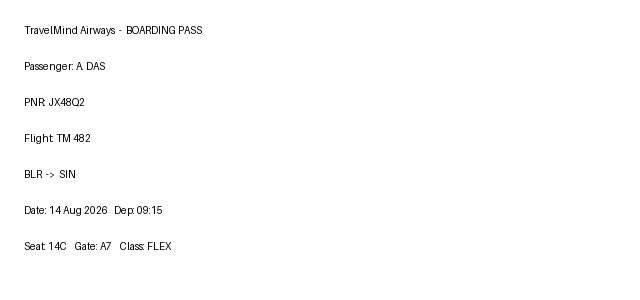

# Boarding Pass Details

**PNR:** JX48Q2

**Flight Number:** TM 482

**Route:** BLR → SIN (Bangalore to Singapore)

**Date:** 14 Aug 2026

**Departure Time:** 09:15

**Seat:** 14C

**Class:** FLEX

---

## Trip Summary

You're all set for your flight from Bangalore to Singapore on August 14th, 2026, departing at 9:15 AM with TravelMind Airways! Your flexible ticket gives you great options, and you'll be comfortable in seat 14C for this exciting journey.

[input tokens incl. image: 296]


In [12]:
from PIL import Image, ImageDraw
IMG_PATH = "ticket.png"

# --- draw a simple synthetic boarding pass so the lesson is self-contained ---
img = Image.new("RGB", (640, 300), "white")
d = ImageDraw.Draw(img)
lines = ["TravelMind Airways  -  BOARDING PASS",
         "Passenger: A. DAS", "PNR: JX48Q2", "Flight: TM 482",
         "BLR  ->  SIN", "Date: 14 Aug 2026   Dep: 09:15",
         "Seat: 14C    Gate: A7    Class: FLEX"]
for i, ln in enumerate(lines):
    d.text((24, 24 + i * 36), ln, fill="black")
img.save(IMG_PATH)
try:
    from IPython.display import display
    display(img)
except Exception:
    pass

with open(IMG_PATH, "rb") as f:
    img_bytes = f.read()

resp = bedrock.converse(
    modelId=MODEL_ID,
    messages=[{"role": "user", "content": [
        {"text": "Extract PNR, flight number, route, date, departure time, seat, and class. "
                 "Then summarize the trip for the passenger in two friendly sentences."},
        {"image": {"format": "png", "source": {"bytes": img_bytes}}}]}],
    inferenceConfig={"maxTokens": 600, "temperature": 0.0})

print(resp["output"]["message"]["content"][0]["text"])
print()
print(f"[input tokens incl. image: {resp['usage']['inputTokens']}]")

# For a PDF instead of an image, swap the image block for:
# {"document": {"format": "pdf", "name": "ticket", "source": {"bytes": pdf_bytes}}}

## Production notes

- Auth: IAM roles, never access keys. IAM action is `bedrock:InvokeModel` (not `bedrock:Converse`).
- Use the `us.` inference-profile IDs — the bare IDs will not work on-demand for these models.
- Keep `temperature=0` for deterministic flows (refunds, extraction).
- Cap `maxTokens` and enforce `MAX_TURNS` to bound cost.
- Log `usage` per call and push token/cost/latency to CloudWatch (see the masterclass notebook).
- Never log PNRs or passenger data in plaintext.
- The refund boundary is the *absence* of an execution tool. Keep it that way.